In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from textblob import TextBlob
from sklearn.preprocessing import LabelEncoder


df = pd.read_json("Industrial_and_Scientific_5.json", lines=True)
df = df[["summary", "reviewText", "overall", "reviewerID", "asin"]].dropna().reset_index(drop=True)
df["text"] = df["summary"] + " " + df["reviewText"]
df = df.head(2000)

df["user_item"] = df["reviewerID"] + "_" + df["asin"]

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df["user_id"] = user_encoder.fit_transform(df["reviewerID"])
df["item_id"] = item_encoder.fit_transform(df["asin"])

In [2]:
# Sentiment score
df["sentiment"] = df["text"].apply(lambda x: TextBlob(x).sentiment.polarity)


In [3]:
# TF-IDF similarity
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["text"])
tfidf_sim = cosine_similarity(tfidf_matrix)


In [6]:
# Hybrid similarity
hybrid_sim = tfidf_sim

def hybrid_score(index, top_n=5):
    scores = list(enumerate(hybrid_sim[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    indices = [i for i, _ in scores]
    avg_rating = df.iloc[indices]["overall"].mean()
    avg_sentiment = df.iloc[indices]["sentiment"].mean()
    return 0.6 * avg_rating + 0.4 * (avg_sentiment * 5)

df["enhanced_rating"] = [
    0.5 * df.iloc[i]["overall"] + 0.5 * hybrid_score(i)
    for i in range(len(df))
]

df[["summary", "reviewText", "overall", "sentiment", "enhanced_rating"]].to_csv("enhanced_output_advanced.csv", index=False)

def recommend_items(index, top_n=5):
    scores = list(enumerate(hybrid_sim[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    indices = [i for i, _ in scores]
    recommendations = df.iloc[indices][["summary", "reviewText", "overall", "enhanced_rating"]]
    print(f"Top {top_n} recommendations for item {index}:")
    for i, row in recommendations.iterrows():
        print(f"\n--- Recommendation {i} ---")
        print(f"Summary: {row['summary']}")
        print(f"Review: {row['reviewText']}")
        print(f"Enhanced Rating: {row['enhanced_rating']:.2f}")

recommend_items(0)

Top 5 recommendations for item 0:

--- Recommendation 120 ---
Summary: Five Stars
Review: great paper and works really well.
Enhanced Rating: 4.73

--- Recommendation 887 ---
Summary: Pleasantly surprised.
Review: Really a great heavyweight can. I was not expecting it to be as good as it really is.
Enhanced Rating: 4.32

--- Recommendation 2 ---
Summary: Handy!
Review: Worked great for my lapping bench.  I would like it if the adhesive were backed with waxed paper for storage and keeping the grit out, but all but the first 6 inches or so still functioned when it arrived.  I used rubber cement to remedy that.
Enhanced Rating: 4.04

--- Recommendation 25 ---
Summary: Five Stars
Review: Great sandpaper
Enhanced Rating: 4.33

--- Recommendation 1407 ---
Summary: Excellent Velcro!
Review: The width is a true 3/4" and what is nice is when both sides are attached, the total thickness is less than 2mm, that's thin!  And, the backed adhesive is the strongest I've ever seen!!  When touched by yo

In [7]:
def generate_html_recommendations(index, top_n=5, output_file="recommendations.html"):
    scores = list(enumerate(hybrid_sim[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    indices = [i for i, _ in scores]
    recommendations = df.iloc[indices][["summary", "reviewText", "overall", "enhanced_rating"]]
    
    html = f"""
    <html>
    <head>
        <title>Top {top_n} Recommendations for Item {index}</title>
        <style>
            body {{ font-family: Arial, sans-serif; padding: 20px; }}
            .rec {{ border: 1px solid #ddd; padding: 15px; margin-bottom: 10px; border-radius: 8px; }}
            .rating {{ color: #f39c12; font-weight: bold; }}
        </style>
    </head>
    <body>
        <h1>Top {top_n} Recommendations for Item {index}</h1>
    """

    for _, row in recommendations.iterrows():
        html += f"""
        <div class="rec">
            <h2>{row['summary']}</h2>
            <p>{row['reviewText']}</p>
            <p class="rating">Original Rating: {row['overall']:.2f}</p>
            <p class="rating">Enhanced Rating: {row['enhanced_rating']:.2f}</p>
        </div>
        """

    html += "</body></html>"

    with open(output_file, "w", encoding="utf-8") as f:
        f.write(html)
    print(f"Recommendations saved to {output_file}")

generate_html_recommendations(0)

Recommendations saved to recommendations.html


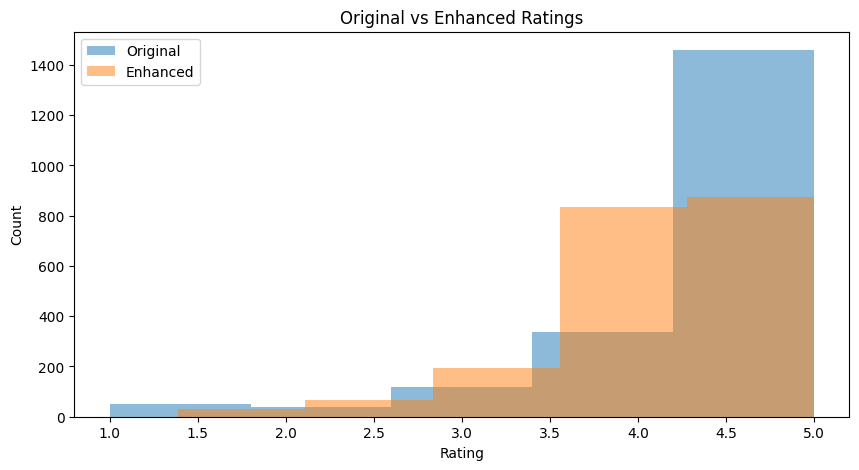

In [8]:
import matplotlib.pyplot as plt  

plt.figure(figsize=(10, 5))
plt.hist(df['overall'], bins=5, alpha=0.5, label='Original')
plt.hist(df['enhanced_rating'], bins=5, alpha=0.5, label='Enhanced')
plt.title('Original vs Enhanced Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend()
plt.show()